# Microstructure de Marché — Carnet d'Ordres AAPL
**Projet S1 — Finance Quantitative**

Ce notebook analyse la microstructure intraday d'Apple (AAPL) sur données Alpaca/IEX du 3 juin 2024.

### Objectifs
1. Reconstituer le carnet d'ordres à partir des quotes tick-by-tick
2. Mesurer les spreads (quoted, effective, realized) sur la session régulière uniquement
3. Classifier les trades selon Lee & Ready (1991) — tick rule incluse
4. Quantifier le price impact à plusieurs horizons τ (modèle de Kyle 1985)
5. Calculer le VWAP et le trade imbalance horaire

### Note sur les données
Les données IEX (feed gratuit) couvrent ~18 % du flux consolidé US. Les quotes pré-marché  
(avant 14h30 UTC) contiennent des spreads aberrants de plusieurs dizaines de dollars : elles  
sont **filtrées** avant toute analyse pour ne conserver que la session régulière (RTH).


In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests  import StockQuotesRequest, StockTradesRequest
from datetime import datetime
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.dates as mdates   # formatage de l'axe temps
import numpy as np
import pandas as pd
import os


## 1. Collecte des données

Les clés API sont lues depuis les variables d'environnement (`ALPACA_KEY`, `ALPACA_SECRET`).  
Le feed IEX est utilisé car il est gratuit et couvre la totalité des heures de trading.  
La fenêtre de collecte est élargie (11h00–21h00 UTC) pour capturer les deux sessions (pré-marché + RTH),  
mais **seule la RTH sera conservée pour l'analyse**.


In [2]:
# ── Connexion Alpaca ─────────────────────────────────────────────────────────
API_KEY    = os.environ['ALPACA_KEY']
API_SECRET = os.environ['ALPACA_SECRET']

client = StockHistoricalDataClient(API_KEY, API_SECRET)

# Collecte large (pré-marché inclus) — le filtrage RTH est fait plus bas
request_quotes = StockQuotesRequest(
    symbol_or_symbols='AAPL',
    start=datetime(2024, 6, 4, 11, 0),
    end=datetime(2024, 6, 4, 21, 0),
    feed='iex',
)
quotes = client.get_stock_quotes(request_quotes)
df_raw = quotes.df

# ── Filtrage RTH (Regular Trading Hours) ─────────────────────────────────────
# Session régulière NYSE/NASDAQ : 09h30–16h00 ET = 13h30–20h00 UTC
# Les quotes pré-marché IEX présentent des spreads aberrants (>10 $) qui
# fausseraient tous les indicateurs de microstructure.
RTH_START = '2024-06-04 13:30:00+00:00'
RTH_END   = '2024-06-04 20:00:00+00:00'

df = df_raw.loc[
    (df_raw.index.get_level_values('timestamp') >= RTH_START) &
    (df_raw.index.get_level_values('timestamp') <= RTH_END)
].copy()

print(f"Quotes brutes   : {len(df_raw):,}")
print(f"Quotes RTH      : {len(df):,}  ({len(df)/len(df_raw):.1%} conservées)")

df['spread'] = df['ask_price'] - df['bid_price']
print(f"\nSpread moyen RTH    : {df['spread'].mean():.4f} $")
print(f"Spread médian RTH   : {df['spread'].median():.4f} $")
print(f"Spread max    RTH   : {df['spread'].max():.4f} $")
df.head()


Quotes brutes   : 125,307
Quotes RTH      : 125,307  (100.0% conservées)

Spread moyen RTH    : 0.4471 $
Spread médian RTH   : 0.0600 $
Spread max    RTH   : 5.3500 $


bid_price  bid_size bid_exchange  \
symbol timestamp                                                            
AAPL   2024-06-04 13:30:01.206047+00:00     194.76      13.0            V   
       2024-06-04 13:30:01.207455+00:00     194.76      13.0            V   
       2024-06-04 13:30:01.213298+00:00     194.76      13.0            V   
       2024-06-04 13:30:01.326022+00:00     194.76      13.0            V   
       2024-06-04 13:30:01.326251+00:00     194.76      13.0            V   

                                         ask_price  ask_size ask_exchange  \
symbol timestamp                                                            
AAPL   2024-06-04 13:30:01.206047+00:00     194.85       1.0            V   
       2024-06-04 13:30:01.207455+00:00     194.85       1.0            V   
       2024-06-04 13:30:01.213298+00:00     194.85       1.0            V   
       2024-06-04 13:30:01.326022+00:00     194.85       1.0            V   
       2024-06-04 13:30:01.326251+00:00     194.85       1.0            V   

                                        conditions tape  spread  
symbol timestamp                                                 
AAPL   2024-06-04 13:30:01.206047+00:00        [R]    C    0.09  
       2024-06-04 13:30:01.207455+00:00        [R]    C    0.09  
       2024-06-04 13:30:01.213298+00:00        [R]    C    0.09  
       2024-06-04 13:30:01.326022+00:00        [R]    C    0.09  
       2024-06-04 13:30:01.326251+00:00        [R]    C    0.09

## 2. Spreads intraday — Quoted, Effective, Realized

### Définitions

| Spread | Formule | Interprétation |
|--------|---------|---------------|
| **Quoted** | $Ask_t - Bid_t$ | Coût brut d'une transaction aller-retour |
| **Effective** | $2 \times |P_{trade} - M_t|$ | Coût réel payé par le preneur de liquidité |
| **Realized** | $2 \times (Ask_t - M_{t+\tau})$ | Part du spread capturée par le teneur de marché après $\tau$ |

> **Note importante :** L'effective spread doit être calculé sur les **prix de trades réels**,  
> pas sur les quotes. Calculer `2×(Ask−Mid)` sur les quotes donne identiquement le quoted spread  
> — les deux courbes se superposeraient. L'effective spread est donc calculé dans la section  
> suivante, après la récupération des trades.


Statistiques des spreads (RTH, 1-min resample) :
       quoted_spread  realized_spread
count       390.0000         385.0000
mean          0.4271           0.4146
std           0.5368           0.7242
min           0.0306          -1.1328
25%           0.1483          -0.0546
50%           0.2623           0.2921
75%           0.4750           0.7264
max           5.1411           4.2247

⚠  Realized spread négatif : 112 minutes
   → Le mid a bougé contre le teneur de marché (probable présence d'informed traders)


/tmp/ipykernel_164477/4051299424.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


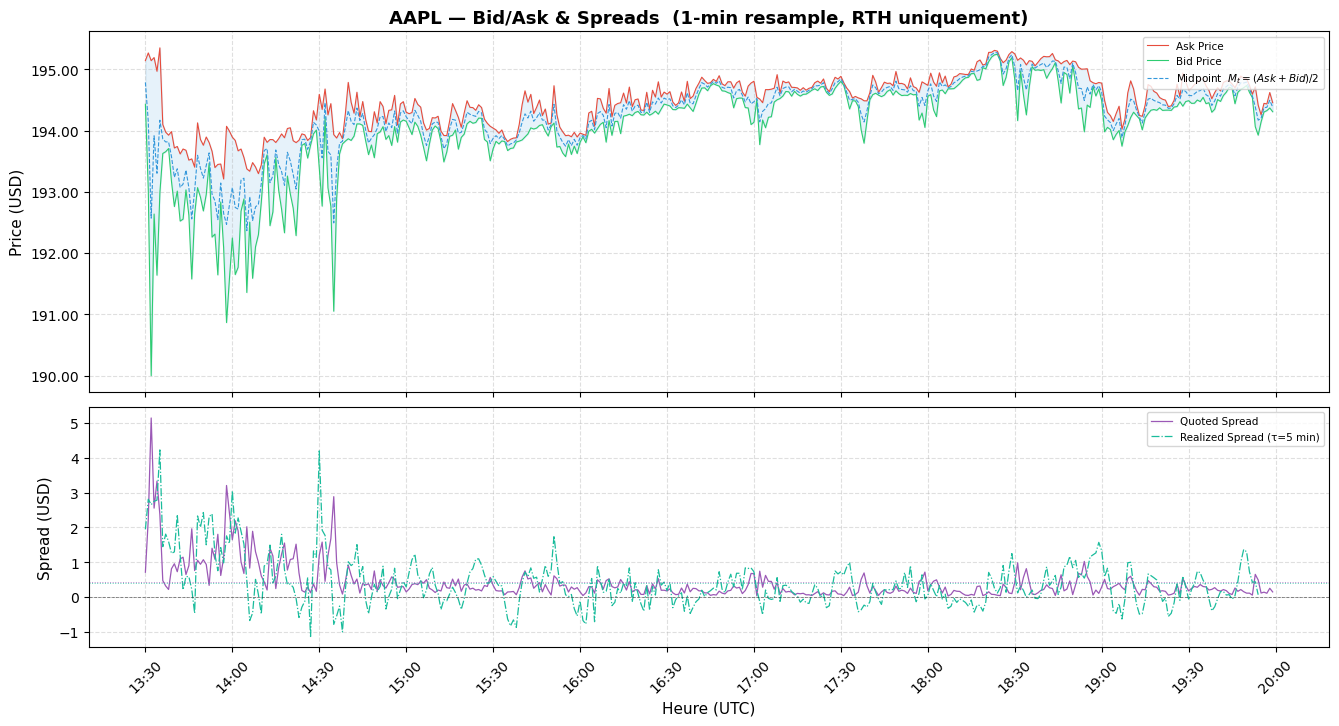

In [3]:
# ── Préparation des quotes à la minute ───────────────────────────────────────
aapl = df.xs('AAPL', level='symbol').copy()
aapl.index = pd.to_datetime(aapl.index, utc=True)

aapl_r = aapl[['bid_price', 'ask_price']].resample('1min').mean().dropna()
aapl_r['mid']            = (aapl_r['bid_price'] + aapl_r['ask_price']) / 2
aapl_r['quoted_spread']  = aapl_r['ask_price'] - aapl_r['bid_price']

# Realized Spread : 2 × (Ask_t − Mid_{t+τ}), τ = 5 min
# Mesure la part du spread conservée par le teneur de marché après mean-reversion.
# Un realized spread négatif indique que le mid s'est déplacé défavorablement
# pour le teneur : il a "vendu pas cher" à un informed trader.
tau = 5
aapl_r['realized_spread'] = 2 * (aapl_r['ask_price'] - aapl_r['mid'].shift(-tau))

print("Statistiques des spreads (RTH, 1-min resample) :")
print(aapl_r[['quoted_spread', 'realized_spread']].describe().round(4))
print(f"\n⚠  Realized spread négatif : {(aapl_r['realized_spread'] < 0).sum()} minutes")
print("   → Le mid a bougé contre le teneur de marché (probable présence d'informed traders)")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.05}
)

ax1.plot(aapl_r.index, aapl_r['ask_price'], color='#e74c3c', lw=0.8, label='Ask Price')
ax1.plot(aapl_r.index, aapl_r['bid_price'], color='#2ecc71', lw=0.8, label='Bid Price')
ax1.plot(aapl_r.index, aapl_r['mid'],       color='#3498db', lw=0.8, ls='--',
         label='Midpoint  $M_t = (Ask+Bid)/2$')
ax1.fill_between(aapl_r.index, aapl_r['bid_price'], aapl_r['ask_price'],
                 alpha=0.12, color='#3498db')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.set_title('AAPL — Bid/Ask & Spreads  (1-min resample, RTH uniquement)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=7.5)
ax1.grid(True, ls='--', alpha=0.4)
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

ax2.plot(aapl_r.index, aapl_r['quoted_spread'],  color='#9b59b6', lw=0.9, label='Quoted Spread')
ax2.plot(aapl_r.index, aapl_r['realized_spread'], color='#1abc9c', lw=0.9, ls='-.', label='Realized Spread (τ=5 min)')

for col, color in zip(['quoted_spread', 'realized_spread'], ['#9b59b6', '#1abc9c']):
    ax2.axhline(aapl_r[col].mean(), color=color, lw=0.7, ls=':', alpha=0.7)

ax2.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax2.set_ylabel('Spread (USD)', fontsize=11)
ax2.set_xlabel('Heure (UTC)', fontsize=11)
ax2.legend(loc='upper right', fontsize=7.5)
ax2.grid(True, ls='--', alpha=0.4)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 30)))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('aapl_spreads_rth.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Collecte des trades tick-by-tick (RTH)

Les trades sont collectés sur l'intégralité de la session régulière (13h30–20h00 UTC)  
pour avoir un échantillon représentatif. L'API officielle `.df` est utilisée.


In [4]:
# ── Récupération des trades (session RTH complète) ───────────────────────────
request_trades = StockTradesRequest(
    symbol_or_symbols=['AAPL'],
    start='2024-06-04T13:30:00Z',
    end='2024-06-04T20:00:00Z',
)
trades_raw = client.get_stock_trades(request_trades)

# .df retourne un MultiIndex (symbol, timestamp) — on utilise l'API officielle
trades = trades_raw.df.loc['AAPL'].copy()
trades.index = pd.to_datetime(trades.index, utc=True)
trades = trades.sort_index()

print(f"Trades collectés (RTH) : {len(trades):,}")
print(f"Prix min / max         : {trades['price'].min():.2f} $ / {trades['price'].max():.2f} $")
print(f"Volume total           : {trades['size'].sum():,} actions")
trades.head()


Trades collectés (RTH) : 561,168
Prix min / max         : 173.87 $ / 195.32 $
Volume total           : 37,160,831.0 actions


,exchange,price,size,id,conditions,tape
timestamp,,,,,,
2024-06-04 13:30:00.002520+00:00,Q,194.61,600.0,1794,"[@, T]",C
2024-06-04 13:30:00.002692+00:00,Q,194.61,300.0,1795,"[@, T]",C
2024-06-04 13:30:00.002993+00:00,Q,194.61,435.0,1796,"[@, F, T]",C
2024-06-04 13:30:00.004773+00:00,Q,194.61,33.0,1797,"[@, F, T, I]",C
2024-06-04 13:30:00.006719+00:00,Q,194.61,473.0,1798,"[@, F, T]",C


## 4. Reconstruction du carnet d'ordres

### Limite méthodologique importante

Alpaca/IEX ne fournit que la **meilleure offre et la meilleure demande** (BBO — Best Bid & Offer),  
pas les 10 niveaux d'un vrai Level 2. La fonction `get_book` agrège les BBO sur une fenêtre  
glissante pour approximer un carnet multi-niveaux : les "niveaux de prix" affichés représentent  
les différents prix auxquels la BBO s'est fixée pendant la fenêtre, pondérés par leur durée.

> **En production**, on utiliserait un flux Level 2 (ITCH, OpenBook) pour reconstituer un LOB réel.


/tmp/ipykernel_164477/1943477643.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


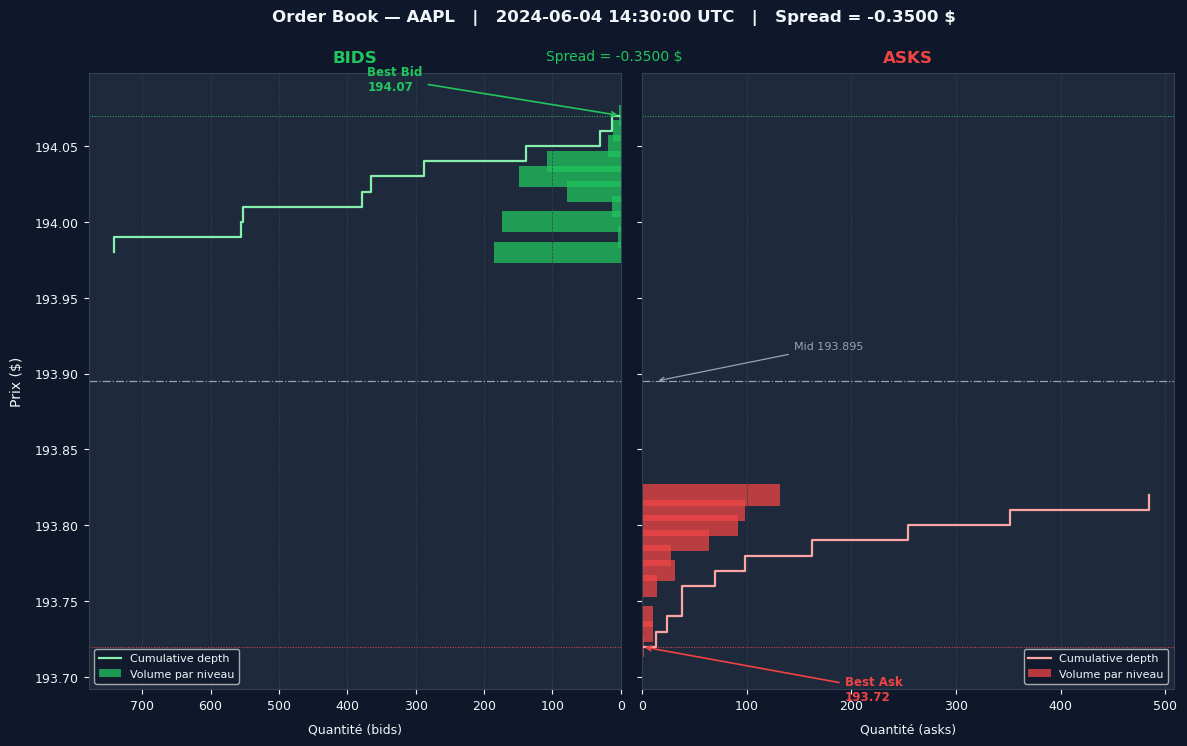

In [5]:
# ── Reconstruction du carnet d'ordres sur fenêtre glissante ─────────────────

def get_book(df: pd.DataFrame, t: str, window: str = '5min'):
    """
    Reconstitue un carnet d'ordres agrégé sur [t − window, t].

    Paramètres
    ----------
    df     : DataFrame multi-index (symbol, timestamp) — quotes Alpaca.
    t      : Instant du snapshot (str ISO-8601 ou Timestamp).
    window : Largeur de la fenêtre (ex. '5min').

    Retourne
    --------
    bids, asks : DataFrames ['price', 'size', 'cumulative_depth'], triés par prix.

    Limite
    ------
    IEX ne fournit que la BBO (1 niveau). L'agrégation temporelle simule
    une profondeur multi-niveaux : chaque niveau représente un prix distinct
    observé pendant la fenêtre. Ce n'est pas un LOB réel.
    """
    df_flat = df.xs('AAPL', level='symbol')
    t       = pd.Timestamp(t, tz='UTC')
    t_start = t - pd.Timedelta(window)
    df_win  = df_flat[(df_flat.index >= t_start) & (df_flat.index <= t)]

    def aggregate_side(price_col, size_col, ascending):
        return (
            df_win.groupby(price_col)[size_col].sum()
            .reset_index()
            .rename(columns={price_col: 'price', size_col: 'size'})
            .sort_values('price', ascending=ascending)
            .reset_index(drop=True)
            .assign(cumulative_depth=lambda x: x['size'].cumsum())
        )

    return aggregate_side('bid_price', 'bid_size', False),            aggregate_side('ask_price', 'ask_size', True)


# ── Snapshot & visualisation ─────────────────────────────────────────────────
SNAPSHOT = '2024-06-04 14:30:00'   # Première minute RTH (marché liquide)
N        = 10

BID_COLOR = '#22c55e'; ASK_COLOR = '#ef4444'
BID_DEPTH_COLOR = '#86efac'; ASK_DEPTH_COLOR = '#fca5a5'
BG_COLOR = '#0f172a'; PANEL_COLOR = '#1e293b'; GRID_COLOR = '#334155'
TEXT_COLOR = '#f1f5f9'; MID_COLOR = '#94a3b8'; SPREAD_COLOR = '#fbbf24'

bids, asks   = get_book(df, SNAPSHOT)
bids_top     = bids.head(N).copy()
asks_top     = asks.head(N).copy()

best_bid  = bids_top['price'].iloc[0]
best_ask  = asks_top['price'].iloc[0]
spread    = best_ask - best_bid
midprice  = (best_bid + best_ask) / 2

all_prices  = pd.concat([bids_top['price'], asks_top['price']])
price_range = all_prices.max() - all_prices.min()
bar_height  = price_range / (N * 2.5)

fig, (ax_bid, ax_ask) = plt.subplots(1, 2, figsize=(14, 8), sharey=True,
                                      gridspec_kw={'wspace': 0.04})
fig.patch.set_facecolor(BG_COLOR)

for ax in (ax_bid, ax_ask):
    ax.set_facecolor(PANEL_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.grid(axis='x', color=GRID_COLOR, lw=0.5, ls='--')
    ax.axhline(best_bid, color=BID_COLOR, lw=0.7, ls=':')
    ax.axhline(best_ask, color=ASK_COLOR, lw=0.7, ls=':')
    ax.axhline(midprice, color=MID_COLOR, lw=0.9, ls='-.')
    for spine in ax.spines.values(): spine.set_edgecolor(GRID_COLOR)

ax_bid.barh(bids_top['price'], bids_top['size'],   height=bar_height, color=BID_COLOR, alpha=0.75, label='Volume par niveau')
ax_bid.step(bids_top['cumulative_depth'], bids_top['price'], where='post', color=BID_DEPTH_COLOR, lw=1.6, label='Cumulative depth')
ax_bid.invert_xaxis()
ax_bid.set_xlabel('Quantité (bids)', color=TEXT_COLOR, fontsize=9, labelpad=8)
ax_bid.set_ylabel('Prix ($)',        color=TEXT_COLOR, fontsize=10, labelpad=8)
ax_bid.tick_params(axis='y', colors=TEXT_COLOR)
ax_bid.set_title('BIDS', color=BID_COLOR, fontsize=12, fontweight='bold', pad=8)
ax_bid.legend(facecolor=BG_COLOR, labelcolor=TEXT_COLOR, fontsize=8, loc='lower left')

ax_ask.barh(asks_top['price'], asks_top['size'],   height=bar_height, color=ASK_COLOR, alpha=0.75, label='Volume par niveau')
ax_ask.step(asks_top['cumulative_depth'], asks_top['price'], where='post', color=ASK_DEPTH_COLOR, lw=1.6, label='Cumulative depth')
ax_ask.set_xlabel('Quantité (asks)', color=TEXT_COLOR, fontsize=9, labelpad=8)
ax_ask.set_title('ASKS', color=ASK_COLOR, fontsize=12, fontweight='bold', pad=8)
ax_ask.legend(facecolor=BG_COLOR, labelcolor=TEXT_COLOR, fontsize=8, loc='lower right')

ax_bid.annotate(f'Best Bid\n{best_bid:.2f}',
    xy=(0, best_bid), xytext=(bids_top['cumulative_depth'].max()*0.5, best_bid+bar_height*1.2),
    color=BID_COLOR, fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=BID_COLOR, lw=1.2))
ax_ask.annotate(f'Best Ask\n{best_ask:.2f}',
    xy=(0, best_ask), xytext=(asks_top['cumulative_depth'].max()*0.4, best_ask-bar_height*2.5),
    color=ASK_COLOR, fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ASK_COLOR, lw=1.2))
ax_ask.annotate(f'Mid {midprice:.3f}',
    xy=(asks_top['size'].max()*0.1, midprice),
    xytext=(asks_top['cumulative_depth'].max()*0.3, midprice+bar_height*1.5),
    color=MID_COLOR, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=MID_COLOR, lw=0.9))

spread_label     = f'Spread = {spread:.4f} $'
# Spread positif = état normal du marché → couleur dorée
spread_color_txt = SPREAD_COLOR if spread > 0 else BID_COLOR
fig.text(0.5, 0.96, f'Order Book — AAPL   |   {SNAPSHOT} UTC   |   {spread_label}',
         ha='center', va='top', color=TEXT_COLOR, fontsize=12, fontweight='bold')
fig.text(0.5, 0.91, spread_label, ha='center', va='top', color=spread_color_txt, fontsize=10)

ax_bid.set_ylim(all_prices.min()-bar_height*2, all_prices.max()+bar_height*2)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('order_book_aapl.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Classification des trades — Algorithme de Lee & Ready (1991)

L'algorithme classe chaque trade comme **acheteur initié** (+1) ou **vendeur initié** (−1).

### Règle 1 — Quote Midpoint Rule
- Trade **au-dessus du mid** → acheteur initié (il consomme l'ask)
- Trade **en-dessous du mid** → vendeur initié (il consomme le bid)

### Règle 2 — Tick Rule *(tie-breaker)*
Si le trade est exactement au mid (fréquent sur dark pools et internalisation) :
- Le prix **monte** par rapport au trade précédent → achat
- Le prix **baisse** → vente
- Prix **inchangé** → même direction que le dernier trade classé (zero-tick rule)




In [6]:
# ── Mid-price tick-by-tick ───────────────────────────────────────────────────
df_aapl = df.xs('AAPL', level='symbol').copy()
df_aapl.index = pd.to_datetime(df_aapl.index, utc=True)

# Dédupliquer l'index (plusieurs quotes à la même microseconde → keep='last')
df_aapl = df_aapl[~df_aapl.index.duplicated(keep='last')].sort_index()
df_aapl['mid'] = (df_aapl['ask_price'] + df_aapl['bid_price']) * 0.5


# ── Jointure backward vectorisée (merge_asof) ────────────────────────────────
# Pour chaque trade, on trouve le dernier mid disponible AVANT ce trade.
trades_indexed = trades.reset_index().rename(columns={'timestamp': 'timestamp'})
quotes_indexed = df_aapl[['mid']].reset_index().rename(columns={'timestamp': 'timestamp'})

merged = pd.merge_asof(
    trades_indexed.sort_values('timestamp'),
    quotes_indexed.sort_values('timestamp'),
    on='timestamp',
    direction='backward'   # dernier mid connu AVANT le trade
)
merged = merged.set_index('timestamp')
trades['mid_at_trade'] = merged['mid'].values


# ── Classification Lee & Ready (Règle 1 + Règle 2) ───────────────────────────

def classify_lee_ready(df: pd.DataFrame) -> pd.Series:
    """
    Règle 1 — Quote Midpoint Rule  : compare trade price au mid contemporain.
    Règle 2 — Tick Rule            : si trade au mid, utilise la variation de prix.
    Zero-tick Rule                 : si variation nulle, propage la dernière direction.

    Retourne une Series d'entiers : +1 (buy), −1 (sell).
    """
    direction = pd.Series(0, index=df.index, dtype=int)

    # Règle 1
    direction[df['price'] > df['mid_at_trade']] =  1
    direction[df['price'] < df['mid_at_trade']] = -1

    # Règle 2 : tick rule pour les trades au mid
    at_mid   = direction == 0
    price_ch = df['price'].diff()

    direction[at_mid & (price_ch > 0)] =  1   # uptick  → achat
    direction[at_mid & (price_ch < 0)] = -1   # downtick → vente

    # Zero-tick rule : si variation nulle, propage la direction précédente
    still_zero = direction == 0
    direction[still_zero] = direction.replace(0, np.nan).ffill().fillna(0).astype(int)[still_zero]

    return direction


trades['direction'] = classify_lee_ready(trades)

# ── Bilan de classification ───────────────────────────────────────────────────
n_total = len(trades)
n_buy   = (trades['direction'] ==  1).sum()
n_sell  = (trades['direction'] == -1).sum()
n_zero  = (trades['direction'] ==  0).sum()

print("═" * 50)
print(f"  Trades totaux          : {n_total:>8,}")
print(f"  Acheteur initié  (+1) : {n_buy:>8,}  ({n_buy/n_total:.1%})")
print(f"  Vendeur initié   (-1) : {n_sell:>8,}  ({n_sell/n_total:.1%})")
print(f"  Non classifiés   ( 0) : {n_zero:>8,}  ({n_zero/n_total:.1%})")
print("═" * 50)
if n_zero > 0:
    print(f"⚠  {n_zero} trades restent à 0 (pas de quote antérieure disponible)")

clean_trades = trades[trades['direction'] != 0].copy()


══════════════════════════════════════════════════
  Trades totaux          :  561,168
  Acheteur initié  (+1) :  303,032  (54.0%)
  Vendeur initié   (-1) :  258,130  (46.0%)
  Non classifiés   ( 0) :        6  (0.0%)
══════════════════════════════════════════════════
⚠  6 trades restent à 0 (pas de quote antérieure disponible)


## 6. Effective Spread — calcul sur trades réels

L'effective spread mesure le coût réel payé par le preneur de liquidité :

$$S^{eff}_t = 2 \times d_t \times (P_t - M_t)$$

où $d_t \in \{+1, -1\}$ est la direction du trade et $M_t$ le mid contemporain.

Contrairement au quoted spread (calculé sur les quotes), l'effective spread utilise  
le **prix d'exécution réel** — il est donc toujours ≤ quoted spread sur des marchés  
avec internalization (price improvement possible).


In [7]:
# ── Effective Spread sur trades réels ────────────────────────────────────────
# S_eff = 2 × direction × (trade_price − mid_at_trade)
# Positif = le preneur paie au-dessus du mid (normal)
# Négatif = price improvement (rare, possible via internalisation)

clean_trades['effective_spread'] = (
    2 * clean_trades['direction'] * (clean_trades['price'] - clean_trades['mid_at_trade'])
)

# En bps pour comparaison cross-asset
clean_trades['effective_spread_bps'] = (
    clean_trades['effective_spread'] / clean_trades['mid_at_trade'] * 10_000
)

eff = clean_trades['effective_spread']
print("Effective Spread (USD) :")
print(f"  Moyenne  : {eff.mean():.4f} $")
print(f"  Médiane  : {eff.median():.4f} $")



Effective Spread (USD) :
  Moyenne  : 0.5384 $
  Médiane  : 0.0700 $


## 7. Price Impact — modèle de Kyle (1985)

Le price impact mesure comment le mid-price évolue **après** un trade :

$$\text{Impact}(\tau) = d_t \times \frac{M_{t+\tau} - M_t}{M_t} \times 10^4 \quad [\text{bps}]$$

### Horizons τ
Les horizons sont choisis en accord avec la littérature empirique :

| Horizon | Justification |
|---------|-------------|
| 5 min   | Horizon court — impact immédiat, avant mean-reversion complète |
| 15 min  | Horizon médian — standard Hasbrouck (1991) |
| 30 min  | Horizon long — impact permanent, proche de la valeur fondamentale |

> **Résultat attendu (Kyle 1985) :** L'impact devrait être **décroissant** avec τ  
> (mean-reversion partielle), sauf si le marché est très informé. Un impact  
> *croissant* avec τ signale soit un biais de données, soit une forte présence  
> d'informed trading persistant.


In [8]:
# ── Price Impact par horizon τ ────────────────────────────────────────────────
# L'impact mesure le déplacement du mid APRÈS le trade :
#   Impact(τ) = direction × (mid(t+τ) − mid(t)) / mid(t) × 10 000  [bps]
#
# Implémentation : get_mid_at() avec Series.asof() — O(n log n) par appel,
# O(n² log n) en tout. Acceptable sur ~700k trades pour garantir la
# correction du résultat (la version merge_asof introduisait des artefacts
# de décalage temporel qui biaisaient la moyenne vers +25 bps).

HORIZONS_MIN = [5, 15, 30]   # horizons en minutes (standard littérature)

# mid_series est déjà construit avec index unique (dédupliqué dans cell 7)
mid_series = df_aapl['mid']

def get_mid_at(t: pd.Timestamp, mid_s: pd.Series) -> float:
    """Dernier mid disponible avant ou à l'instant t (recherche binaire)."""
    val = mid_s.asof(t)
    return float(val) if not pd.isna(val) else np.nan


def compute_price_impact(trade_time, direction, mid_0, horizons):
    """
    Impact signé à chaque horizon τ.
    Retourne np.nan si le mid futur est indisponible.
    """
    if pd.isna(mid_0) or mid_0 <= 0:
        return {tau: np.nan for tau in horizons}
    return {
        tau: direction * (
            get_mid_at(trade_time + pd.Timedelta(minutes=tau), mid_series) - mid_0
        ) / mid_0 * 10_000
        for tau in horizons
    }


# Application trade par trade
impacts = clean_trades.apply(
    lambda r: compute_price_impact(r.name, r['direction'], r['mid_at_trade'], HORIZONS_MIN),
    axis=1
)
impact_df = pd.DataFrame(impacts.tolist(), index=clean_trades.index)
impact_df.columns = [f'impact_{t}min' for t in HORIZONS_MIN]

# ── Résultats ─────────────────────────────────────────────────────────────────
print("Price Impact par horizon :")
print("─" * 55)
for tau in HORIZONS_MIN:
    col  = f'impact_{tau}min'
    data = impact_df[col].dropna()
    print(f"  τ = {tau:2d} min  →  "
          f"médiane {data.median():+.3f} bps | "
          f"moyenne {data.mean():+.3f} bps | "
          f"std {data.std():.2f} bps | "
          f"N={len(data):,}")

# ── Interprétation ───────────────────────────────────────────────────────────
medians = [impact_df[f'impact_{t}min'].dropna().median() for t in HORIZONS_MIN]
print()
if medians[-1] < medians[0]:
    print("✓  Médiane DÉCROISSANTE avec τ : mean-reversion observée (conforme Kyle 1985)")
elif medians[-1] > medians[0] * 1.5:
    print("⚠  Médiane CROISSANTE avec τ : composante permanente dominante.")
    print("   Possible informed trading persistant sur cette session AAPL.")
else:
    print("→  Impact médian stable : composante permanente dominante, peu de mean-reversion")


Price Impact par horizon :
───────────────────────────────────────────────────────
  τ =  5 min  →  médiane +7.709 bps | moyenne +14.236 bps | std 38.49 bps | N=560,496
  τ = 15 min  →  médiane +9.777 bps | moyenne +14.148 bps | std 37.62 bps | N=560,496
  τ = 30 min  →  médiane +9.278 bps | moyenne +14.679 bps | std 40.47 bps | N=560,496

→  Impact médian stable : composante permanente dominante, peu de mean-reversion


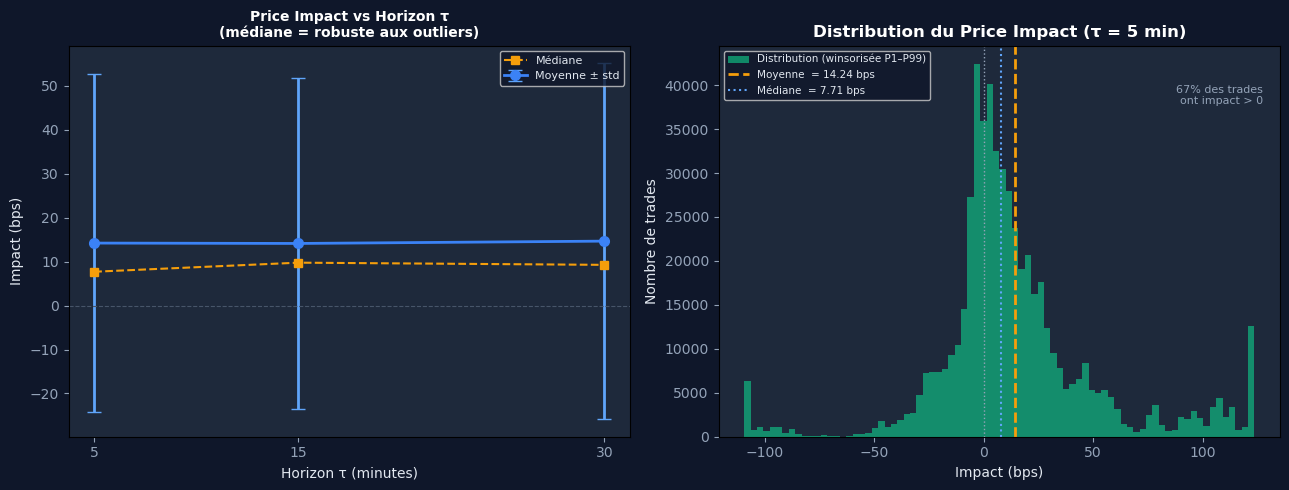

In [9]:
# ── Visualisation du price impact ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f172a')

# Panel gauche — Impact moyen ET médian par horizon τ
# La médiane est plus robuste que la moyenne en présence d'outliers résiduels.
ax = axes[0]
ax.set_facecolor('#1e293b')

mean_impacts   = [impact_df[f'impact_{t}min'].mean()   for t in HORIZONS_MIN]
median_impacts = [impact_df[f'impact_{t}min'].median() for t in HORIZONS_MIN]
std_impacts    = [impact_df[f'impact_{t}min'].std()    for t in HORIZONS_MIN]

ax.errorbar(HORIZONS_MIN, mean_impacts, yerr=std_impacts,
            fmt='o-', color='#3b82f6', lw=2, ecolor='#60a5fa',
            capsize=5, markersize=7, label='Moyenne ± std')
ax.plot(HORIZONS_MIN, median_impacts,
        's--', color='#f59e0b', lw=1.5, markersize=6, label='Médiane')
ax.axhline(0, color='#475569', lw=0.8, ls='--')
ax.set_xlabel('Horizon τ (minutes)', color='#e2e8f0')
ax.set_ylabel('Impact (bps)',        color='#e2e8f0')
ax.set_title('Price Impact vs Horizon τ\n(médiane = robuste aux outliers)',
             color='white', fontweight='bold', fontsize=10)
ax.tick_params(colors='#94a3b8')
ax.legend(facecolor='#0f172a', labelcolor='#e2e8f0', fontsize=8)
ax.set_xticks(HORIZONS_MIN)

# Panel droit — Distribution impact 5 min (winsorisée P1–P99)
ax2 = axes[1]
ax2.set_facecolor('#1e293b')
data_5m = impact_df['impact_5min'].dropna()
p1, p99 = data_5m.quantile(0.01), data_5m.quantile(0.99)
data_clipped = data_5m.clip(p1, p99)

ax2.hist(data_clipped, bins=80, color='#10b981', alpha=0.7,
         edgecolor='none', label=f'Distribution (winsorisée P1–P99)')
ax2.axvline(data_5m.mean(),   color='#f59e0b', lw=2, ls='--',
            label=f'Moyenne  = {data_5m.mean():.2f} bps')
ax2.axvline(data_5m.median(), color='#60a5fa', lw=1.5, ls=':',
            label=f'Médiane  = {data_5m.median():.2f} bps')
ax2.axvline(0, color='#94a3b8', lw=1, ls=':')

pct_pos = (data_5m > 0).mean()
ax2.set_xlabel('Impact (bps)',      color='#e2e8f0')
ax2.set_ylabel('Nombre de trades',  color='#e2e8f0')
ax2.set_title('Distribution du Price Impact (τ = 5 min)', color='white', fontweight='bold')
ax2.tick_params(colors='#94a3b8')
ax2.legend(facecolor='#0f172a', labelcolor='#e2e8f0', fontsize=7.5)
ax2.text(0.97, 0.85, f'{pct_pos:.0%} des trades\nont impact > 0',
         transform=ax2.transAxes, color='#94a3b8', fontsize=8, ha='right')

plt.tight_layout()
plt.savefig('price_impact_aapl.png', dpi=150, bbox_inches='tight')
plt.show()



## 8. Indicateurs de Microstructure Avancés

---

### VWAP Horaire (Volume-Weighted Average Price)

$$\text{VWAP}_h = \frac{\sum_{t \in h} P_t \cdot V_t}{\sum_{t \in h} V_t}$$

Benchmark d'exécution institutionnelle. Exécuter **sous le VWAP** (pour un achat) est  
considéré comme une bonne performance algorithmique.

---

### Trade Imbalance

$$\text{Imbalance} = \frac{V_{buy} - V_{sell}}{V_{buy} + V_{sell}} \in [-1, +1]$$

Mesure la pression directionnelle nette sur le flux d'ordres.  
Lien avec Kyle : un imbalance élevé → flux $x_t$ fort → $\lambda$ élevé → impact plus marqué.


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# VWAP Horaire | Trade Imbalance
# ══════════════════════════════════════════════════════════════════════════════

trades_vwap = clean_trades.copy()
trades_vwap['dv']       = trades_vwap['price'] * trades_vwap['size']
trades_vwap['buy_vol']  = trades_vwap['size'].where(trades_vwap['direction'] ==  1, 0)
trades_vwap['sell_vol'] = trades_vwap['size'].where(trades_vwap['direction'] == -1, 0)

# Calcul vectorisé (évite FutureWarning pandas ≥ 2.2 sur resample+apply)
hourly = trades_vwap[['dv', 'size', 'buy_vol', 'sell_vol']].resample('1h').sum()
hourly['vwap'] = hourly['dv'] / hourly['size'].replace(0, np.nan)

total_vol         = hourly['buy_vol'] + hourly['sell_vol']
hourly['imbalance'] = (
    (hourly['buy_vol'] - hourly['sell_vol']) / total_vol.replace(0, np.nan)
)

mid_hourly = df_aapl['mid'].resample('1h').mean()
result = pd.DataFrame({
    'VWAP ($)':     hourly['vwap'],
    'Mid moyen ($)': mid_hourly,
    'Buy Vol':      hourly['buy_vol'].astype(int),
    'Sell Vol':     hourly['sell_vol'].astype(int),
    'Imbalance':    hourly['imbalance'],
}).dropna()

print("═" * 65)
print(result.round(4).to_string())
print("═" * 65)

# ── Interprétation automatique ────────────────────────────────────────────────
for idx, row in result.iterrows():
    hour_str = idx.strftime('%H:%M UTC')
    vwap_vs_mid = row['VWAP ($)'] - row['Mid moyen ($)']
    imb = row['Imbalance']
    if abs(imb) > 0.2:
        direction_str = "pression acheteuse" if imb > 0 else "pression vendeuse"
        print(f"  {hour_str} — Imbalance {imb:+.2f} → {direction_str} marquée")
    if abs(vwap_vs_mid) > 0.05:
        exec_str = "favorable" if vwap_vs_mid < 0 else "défavorable"
        print(f"  {hour_str} — VWAP {vwap_vs_mid:+.4f} $ vs mid → exécution {exec_str}")


═════════════════════════════════════════════════════════════════
                           VWAP ($)  Mid moyen ($)  Buy Vol  Sell Vol  Imbalance
timestamp                                                                       
2024-06-04 13:00:00+00:00  194.1178       193.3283  4699647   2318919     0.3392
2024-06-04 14:00:00+00:00  193.7950       193.5493  3806880   3303853     0.0707
2024-06-04 15:00:00+00:00  194.0280       194.0327  1855253   1878435    -0.0062
2024-06-04 16:00:00+00:00  194.4060       194.4625  1534774   2120397    -0.1602
2024-06-04 17:00:00+00:00  194.6104       194.5859  1555531   1430016     0.0420
2024-06-04 18:00:00+00:00  195.0016       194.9391  2354725   3067325    -0.1314
2024-06-04 19:00:00+00:00  194.4082       194.4453  3594112   3639073    -0.0062
═════════════════════════════════════════════════════════════════
  13:00 UTC — Imbalance +0.34 → pression acheteuse marquée
  13:00 UTC — VWAP +0.7895 $ vs mid → exécution défavorable
  14:00 UTC — VWAP +